In [113]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score
from sklearn.tree import plot_tree

from sklearn.frozen import FrozenEstimator
from sklearn.inspection import permutation_importance

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
path = "online_gaming_behavior_dataset.csv"
df = pd.read_csv(path)
df['Location'] = df['Location'].replace({'USA': 'America'}) 
df.head()

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,America,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,America,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,America,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium


In [3]:
#copio dataframe e seleziono le colonne da convertire
df_new = df.copy()
df_drop_playerID = df.drop(columns='PlayerID', inplace=False)
obj_cols = df_new.select_dtypes(include=['object']).columns

df_drop_playerID.head()

,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,29,Female,America,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,22,Female,America,Sports,8.223755,0,Easy,16,142,35,41,High
3,35,Male,America,Action,5.265351,1,Easy,9,85,57,47,Medium
4,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium


In [4]:
df_raw = df_drop_playerID.copy()
df_raw['WeeklyTime'] = df_raw['SessionsPerWeek']*df_raw['PlayTimeHours']
df_raw['MonetizationByGenre'] = df_raw['InGamePurchases']*df_raw['GameGenre']
df_raw["AchievementsUnlockedByLevel"] = df_raw["AchievementsUnlocked"] / (df_raw["PlayerLevel"] + 1)
df_raw["PlayerGnre"] = df_raw["PlayerLevel"] * df_raw["GameGenre"]
df_raw['PurchasesPerHour'] = df_raw['InGamePurchases'] / (df_raw['PlayTimeHours']+1)
df_raw['SessionsPerDay'] = df_raw['SessionsPerWeek'] / 7
df_raw['WeeklyInGamePurchases'] = df_raw['InGamePurchases'] / (df_raw['WeeklyTime']+1)
df_raw['LogPlayTime'] = np.log1p(df_raw['PlayTimeHours'])
df_raw['GenreLevel'] = df_raw['GameGenre'].astype(str) + '_' + df_raw['PlayerLevel'].astype(str)
df_raw['SessionsPerAge'] = df_raw['SessionsPerWeek'] / df_raw['Age']
df_raw['EngagementIntensity'] = df_raw['SessionsPerWeek'] * df_raw['AvgSessionDurationMinutes']

df_raw.head()

,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,...,MonetizationByGenre,AchievementsUnlockedByLevel,PlayerGnre,PurchasesPerHour,SessionsPerDay,WeeklyInGamePurchases,LogPlayTime,GenreLevel,SessionsPerAge,EngagementIntensity
0,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,...,,0.312500,StrategyStrategyStrategyStrategyStrategyStrate...,0.000000,0.857143,0.000000,2.849036,Strategy_79,0.139535,648
1,29,Female,America,Strategy,5.525961,0,Medium,5,144,11,...,,0.833333,StrategyStrategyStrategyStrategyStrategyStrate...,0.000000,0.714286,0.000000,1.875788,Strategy_11,0.172414,720
2,22,Female,America,Sports,8.223755,0,Easy,16,142,35,...,,1.138889,SportsSportsSportsSportsSportsSportsSportsSpor...,0.000000,2.285714,0.000000,2.221782,Sports_35,0.727273,2272
3,35,Male,America,Action,5.265351,1,Easy,9,85,57,...,Action,0.810345,ActionActionActionActionActionActionActionActi...,0.159608,1.285714,0.020666,1.835035,Action_57,0.257143,765
4,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,...,,0.385417,ActionActionActionActionActionActionActionActi...,0.000000,0.285714,0.000000,2.805295,Action_95,0.060606,262


In [5]:
df_clean = df_raw.drop(['PlayTimeHours','GenreLevel','PlayerGnre','InGamePurchases','WeeklyTime'],axis=1)

In [6]:
df_raw.drop(['InGamePurchases','WeeklyTime'],axis=1)

,Age,Gender,Location,GameGenre,PlayTimeHours,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,...,MonetizationByGenre,AchievementsUnlockedByLevel,PlayerGnre,PurchasesPerHour,SessionsPerDay,WeeklyInGamePurchases,LogPlayTime,GenreLevel,SessionsPerAge,EngagementIntensity
0,43,Male,Other,Strategy,16.271119,Medium,6,108,79,25,...,,0.312500,StrategyStrategyStrategyStrategyStrategyStrate...,0.000000,0.857143,0.000000,2.849036,Strategy_79,0.139535,648
1,29,Female,America,Strategy,5.525961,Medium,5,144,11,10,...,,0.833333,StrategyStrategyStrategyStrategyStrategyStrate...,0.000000,0.714286,0.000000,1.875788,Strategy_11,0.172414,720
2,22,Female,America,Sports,8.223755,Easy,16,142,35,41,...,,1.138889,SportsSportsSportsSportsSportsSportsSportsSpor...,0.000000,2.285714,0.000000,2.221782,Sports_35,0.727273,2272
3,35,Male,America,Action,5.265351,Easy,9,85,57,47,...,Action,0.810345,ActionActionActionActionActionActionActionActi...,0.159608,1.285714,0.020666,1.835035,Action_57,0.257143,765
4,33,Male,Europe,Action,15.531945,Medium,2,131,95,37,...,,0.385417,ActionActionActionActionActionActionActionActi...,0.000000,0.285714,0.000000,2.805295,Action_95,0.060606,262
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40029,32,Male,America,Strategy,20.619662,Easy,4,75,85,14,...,,0.162791,StrategyStrategyStrategyStrategyStrategyStrate...,0.000000,0.571429,0.000000,3.073603,Strategy_85,0.125000,300
40030,44,Female,Other,Simulation,13.539280,Hard,19,114,71,27,...,,0.375000,SimulationSimulationSimulationSimulationSimula...,0.000000,2.714286,0.000000,2.676854,Simulation_71,0.431818,2166
40031,15,Female,America,RPG,0.240057,Easy,10,176,29,1,...,RPG,0.033333,RPGRPGRPGRPGRPGRPGRPGRPGRPGRPGRPGRPGRPGRPGRPGR...,0.806415,1.428571,0.294068,0.215157,RPG_29,0.666667,1760
40032,34,Male,America,Sports,14.017818,Medium,3,128,70,10,...,Sports,0.140845,SportsSportsSportsSportsSportsSportsSportsSpor...,0.066588,0.428571,0.023227,2.709237,Sports_70,0.088235,384


In [51]:
df_new = df.copy()
df_drop_playerID = df.drop(columns='PlayerID', inplace=False)
obj_cols = df_new.select_dtypes(include=['object']).columns
 
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
data_to_encode = df_drop_playerID[obj_cols]
encoded_data = encoder.fit_transform(data_to_encode)

encoded_df = pd.DataFrame(
    encoded_data, 
    columns=encoder.get_feature_names_out(obj_cols),
    index=df_drop_playerID.index
)

df_final = pd.concat([df_drop_playerID.drop(columns=obj_cols), encoded_df], axis=1)

df_final.head()

,Age,PlayTimeHours,InGamePurchases,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,Gender_Female,Gender_Male,Location_America,...,GameGenre_RPG,GameGenre_Simulation,GameGenre_Sports,GameGenre_Strategy,GameDifficulty_Easy,GameDifficulty_Hard,GameDifficulty_Medium,EngagementLevel_High,EngagementLevel_Low,EngagementLevel_Medium
0,43,16.271119,0,6,108,79,25,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
1,29,5.525961,0,5,144,11,10,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
2,22,8.223755,0,16,142,35,41,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,35,5.265351,1,9,85,57,47,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,33,15.531945,0,2,131,95,37,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


In [52]:
df_final['EngagementLevel'] = df_final[['EngagementLevel_High', 'EngagementLevel_Medium', 'EngagementLevel_Low']].idxmax(axis=1)
df_final['EngagementLevel'] = df_final['EngagementLevel'].str.replace('EngagementLevel_', '')
df_final = df_final.drop(columns=['EngagementLevel_High', 'EngagementLevel_Medium', 'EngagementLevel_Low'])

In [53]:
X = df_final.drop(["EngagementLevel"],axis=1)
y = df_final["EngagementLevel"]

In [54]:

X_train, X_test ,y_train , y_test = train_test_split(X,y,test_size=.2 ,stratify=y) 

In [55]:
df_final.isna().sum()

Age                          0
PlayTimeHours                0
InGamePurchases              0
SessionsPerWeek              0
AvgSessionDurationMinutes    0
PlayerLevel                  0
AchievementsUnlocked         0
Gender_Female                0
Gender_Male                  0
Location_America             0
Location_Asia                0
Location_Europe              0
Location_Other               0
GameGenre_Action             0
GameGenre_RPG                0
GameGenre_Simulation         0
GameGenre_Sports             0
GameGenre_Strategy           0
GameDifficulty_Easy          0
GameDifficulty_Hard          0
GameDifficulty_Medium        0
EngagementLevel              0
dtype: int64

In [ ]:
result = []

for i in range(80,110):
    rf_model = RandomForestClassifier(
    n_estimators=i,
    max_depth=11,
    bootstrap=True,
    oob_score=True,
    random_state=42
)
    rf_model.fit(X_train, y_train)
    pred = rf_model.predict(X_test)
    accur = accuracy_score(y_test,pred)
    print(f"ACC {i}: {accur}")
    result.append(accur)


ACC 80: 0.8821031597352317
ACC 81: 0.8827276133383289
ACC 82: 0.8831022855001873
ACC 83: 0.8823529411764706
ACC 84: 0.8827276133383289
ACC 85: 0.8823529411764706
ACC 86: 0.8828525040589484
ACC 87: 0.8823529411764706
ACC 88: 0.8824778318970901
ACC 89: 0.8818533782939928
ACC 90: 0.8823529411764706
ACC 91: 0.8819782690146122
ACC 92: 0.8818533782939928
ACC 93: 0.8814787061321344
ACC 94: 0.8819782690146122
ACC 95: 0.8817284875733733
ACC 96: 0.8813538154115149
ACC 97: 0.8816035968527538
ACC 98: 0.8817284875733733
ACC 99: 0.8821031597352317
ACC 100: 0.8818533782939928
ACC 101: 0.8822280504558512
ACC 102: 0.8824778318970901
ACC 103: 0.8824778318970901
ACC 104: 0.8822280504558512
ACC 105: 0.8829773947795678
ACC 106: 0.8824778318970901
ACC 107: 0.8823529411764706
ACC 108: 0.8823529411764706
ACC 109: 0.8823529411764706


<Axes: >

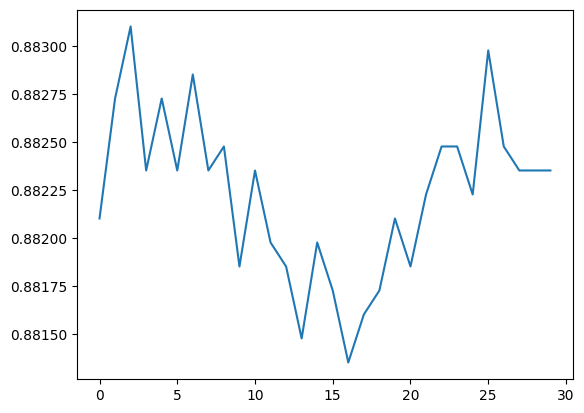

In [93]:
sns.lineplot(data=result)

In [94]:
rf_model = RandomForestClassifier(
    n_estimators=107,
    max_depth=10,
    bootstrap=True,
    oob_score=True,
    random_state=42
)
rf_model.fit(X_train, y_train)
print(f"score: { accuracy_score(y_test,pred)}")



score: 0.8823529411764706


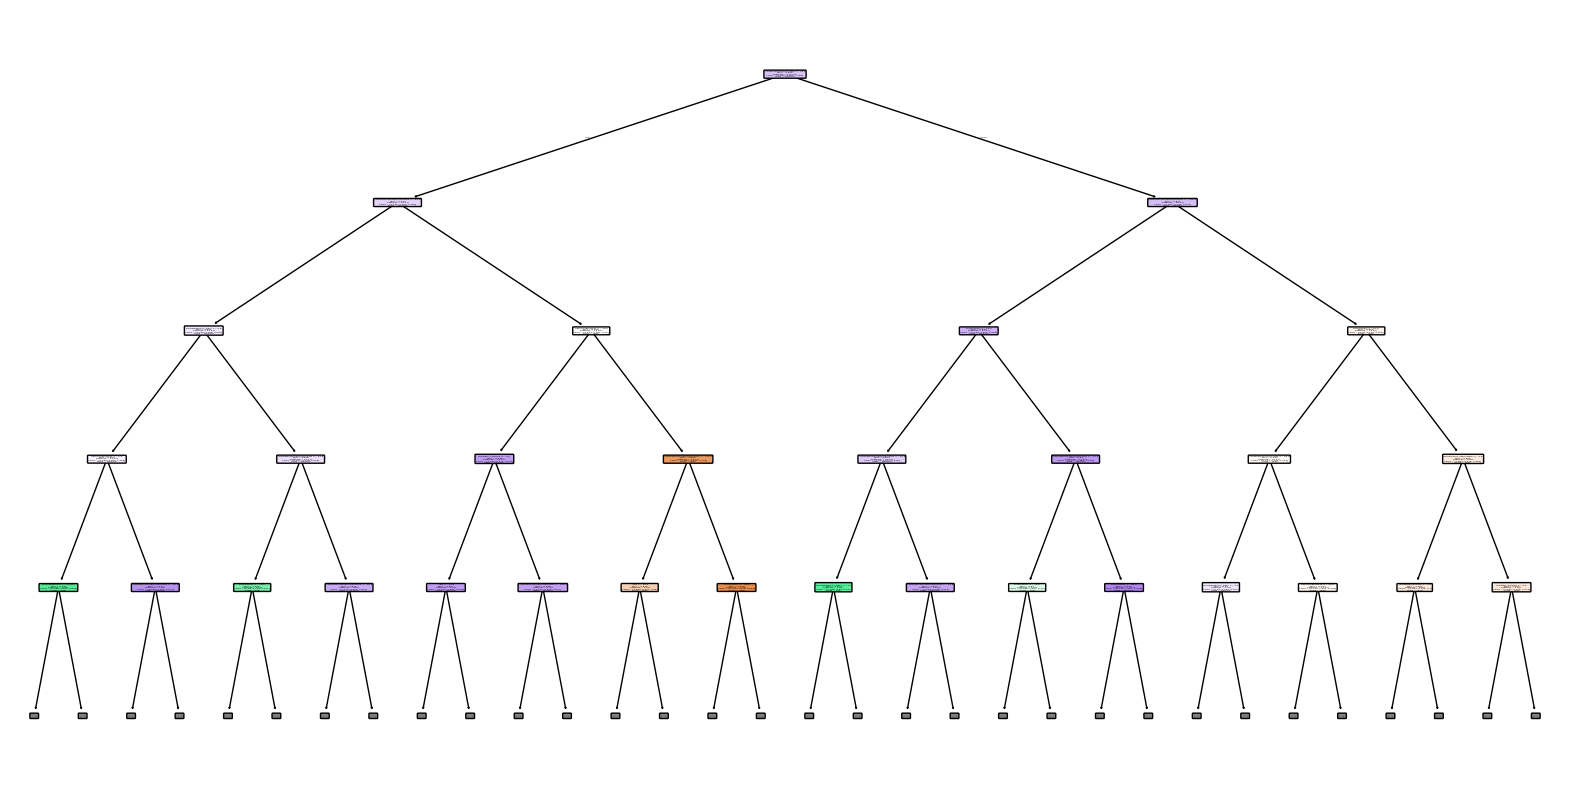

In [ ]:
plt.figure(figsize=(20, 10))
plot_tree(
    rf_model.estimators_[0],  
    max_depth=4,
    filled=True,
    feature_names=X.columns,
    class_names=rf_model.classes_,
    rounded=True,
    proportion=True
)
plt.show()



In [95]:
y_pred_rf = rf_model.predict(X_test)

In [96]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

        High       0.91      0.82      0.86      2067
         Low       0.92      0.78      0.84      2065
      Medium       0.84      0.95      0.89      3875

    accuracy                           0.87      8007
   macro avg       0.89      0.85      0.86      8007
weighted avg       0.88      0.87      0.87      8007



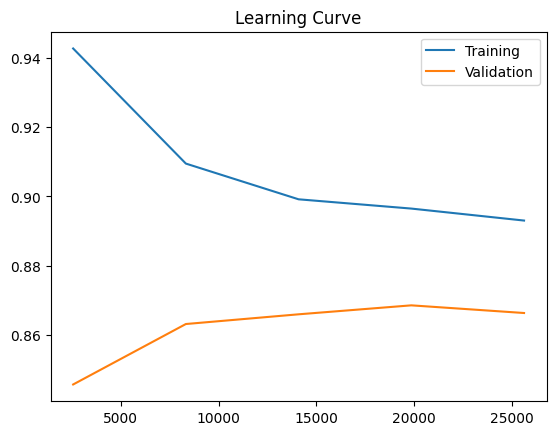

In [97]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

train_sizes, train_scores, test_scores = learning_curve(rf_model, X_train, y_train, cv=5)

plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Training')
plt.plot(train_sizes, np.mean(test_scores, axis=1), label='Validation')
plt.legend()
plt.title('Learning Curve')
plt.show()


In [98]:
accuracy_score(y_test,y_pred_rf)

acc_score = accuracy_score(y_test,y_pred_rf)
train_acc = rf_model.score(X_train, y_train)
test_acc = rf_model.score(X_test, y_test)

print(f"Accuracy train: {train_acc:.3f}")
print(f"Accuracy test:  {test_acc:.3f}")
print(f"Accuracy score:  {acc_score}")


Accuracy train: 0.889
Accuracy test:  0.872
Accuracy score:  0.8717372299238166


 MODEL BALANCED -0.02


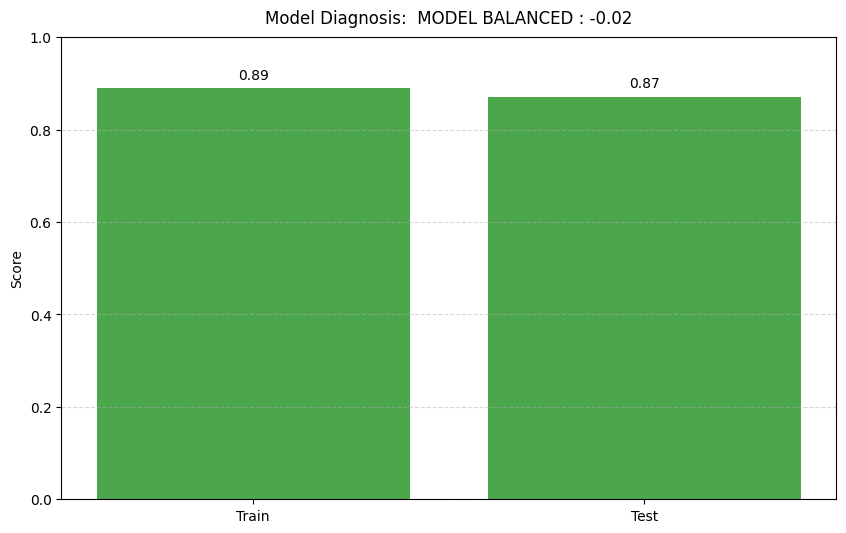

In [99]:
# Calcolo della differenza
spread_score = test_acc - train_acc

# Diagnosi automatica
if spread_score > 0.10:
    status = " OVERFITTING"
    color = "red"
elif spread_score <= -0.05:
    status = " UNDERFITTING"
    color = "blue"
elif train_acc > 0.95 and test_acc > 0.95:
    status = " POSSIBLE DATA LEAKAGE"
    color = "orange"
else:
    status = " MODEL BALANCED"
    color = "green"

print(f"{status} {spread_score:.2f}")

plt.figure(figsize=(10,6))
plt.bar(["Train", "Test"], [train_acc, test_acc], color=[color, color], alpha=0.7)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title(f"Model Diagnosis: {status} : {spread_score:.2f}", fontsize=12, pad=10)
plt.text(0, train_acc + 0.02, f"{train_acc:.2f}", ha='center', color='black', fontsize=10)
plt.text(1, test_acc + 0.02, f"{test_acc:.2f}", ha='center', color='black', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [23]:
new_order = ["High", "Medium", "Low"]
original_labels = rf_model.classes_
cm = confusion_matrix(y_test, y_pred_rf, labels=rf_model.classes_)
cm_df = pd.DataFrame(cm, index=original_labels, columns=original_labels)
cm_df = cm_df.loc[new_order, new_order]
cm_df

,High,Medium,Low
High,1678,329,60
Medium,121,3659,95
Low,55,357,1653


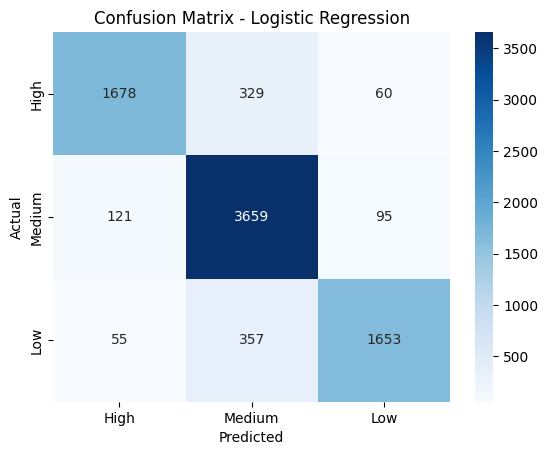

In [24]:
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

In [ ]:
print(y_pred_rf[:10])
print(y_test[:10].values)

['Low' 'Low' 'High' 'High' 'Medium' 'Low' 'Low' 'Low' 'Medium' 'Low']
['Low' 'Low' 'High' 'High' 'High' 'Low' 'Low' 'Low' 'Medium' 'Low']


In [ ]:
y_pred_proba = rf_model.predict_proba(X_test)
print(y_pred_proba[:5])

[[0.06896552 0.81609195 0.11494253]
 [0.01149425 0.63218391 0.35632184]
 [0.93103448 0.         0.06896552]
 [0.64367816 0.04597701 0.31034483]
 [0.06896552 0.11494253 0.81609195]]


In [ ]:
y.value_counts(normalize=True)


EngagementLevel
Medium    0.483939
High      0.258181
Low       0.257881
Name: proportion, dtype: float64

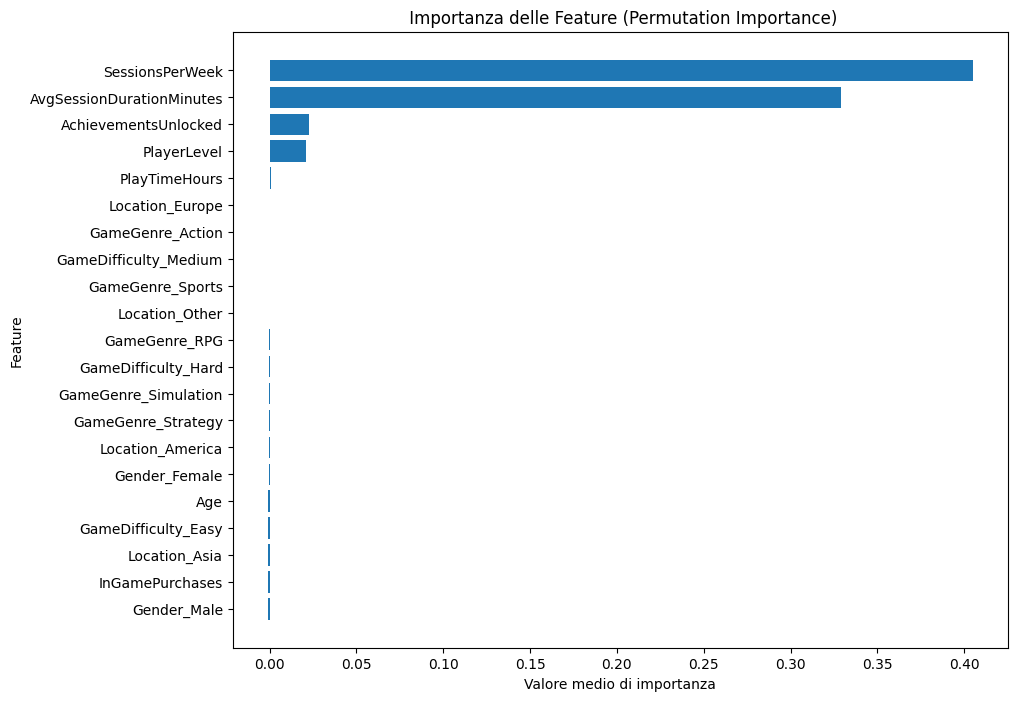

,Feature,Importance
8,Gender_Male,-0.000862
2,InGamePurchases,-0.000737
10,Location_Asia,-0.000737
18,GameDifficulty_Easy,-0.000687
0,Age,-0.000649
7,Gender_Female,-0.000412
9,Location_America,-0.000400
17,GameGenre_Strategy,-0.000400
15,GameGenre_Simulation,-0.000287
19,GameDifficulty_Hard,-0.000125


In [ ]:
result = permutation_importance(rf_model, X_test, y_test, n_repeats=10, random_state=42)

importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': result.importances_mean
}).sort_values(by='Importance', ascending=True)


plt.figure(figsize=(10, 8))
plt.barh(importances['Feature'], importances['Importance'])
plt.title(' Importanza delle Feature (Permutation Importance)')
plt.xlabel('Valore medio di importanza')
plt.ylabel('Feature')
plt.show()

importances.head(23)


In [ ]:
def test_player(model, X_columns, **kwargs):
    """
    Funzione per testare automaticamente un nuovo giocatore.

    Parametri:
        model      -> modello addestrato (es. log_model)
        X_columns  -> colonne originali del training (X.columns)
        kwargs     -> valori noti del nuovo giocatore (es. Age=25, PlayTimeHours=10, ecc.)
    
    Output:
        - Predizione della classe (High / Medium / Low)
        - Probabilità per ciascuna classe
    """
    
    # Crea un dizionario con tutte le colonne, impostando a 0 quelle mancanti
    nuovo_record = {col: kwargs.get(col, 0) for col in X_columns}
    
    # Trasforma in DataFrame
    df_4_pred = pd.DataFrame([nuovo_record])
        
    # Predizione
    pred = model.predict(df_4_pred)[0]
    prob = model.predict_proba(df_4_pred)[0]
    
    # Output formattato
    result = pd.DataFrame({
        'Classe': model.classes_,
        'Probabilità': np.round(prob, 3)
    })
    
    print("🎯 Predizione finale:", pred)
    print("\n📊 Dettaglio probabilità:\n")
    display(result.sort_values(by='Probabilità', ascending=False))
    
    return pred, result


In [ ]:
test_player(
    rf_model, 
    X.columns,
    Age=35,
    PlayTimeHours=62,
    InGamePurchases=2,
    SessionsPerWeek=5,
    AvgSessionDurationMinutes=95,
    PlayerLevel=0.5,
    AchievementsUnlocked=85,
    Gender_Male=1,
    Location_Asia =0,
    Location_Other = 1,
  
)
# FEATURE NON RILEVANTI
# GameGenre_Simulation	
# GameGenre_Strategy	
# Gender_Female	
# Location_America	
# GameDifficulty_Easy	
# GameDifficulty_Hard	
# GameGenre_Sports	
# GameDifficulty_Medium	
# Location_Europe	
# GameGenre_Action	
# GameGenre_RPG	

🎯 Predizione finale: Medium

📊 Dettaglio probabilità:



,Classe,Probabilità
2,Medium,0.563
1,Low,0.264
0,High,0.172


('Medium',
    Classe  Probabilità
 0    High        0.172
 1     Low        0.264
 2  Medium        0.563)